In [62]:
import colorcet
import h5py
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from lib.plots import attach_colorbar, set_axis
from lib.stats import fit_power_law

In [63]:
task_id = "7-acetylation_sweep"
msd_cutoff_frame = 11
frame_duration = 0.05

metrics_table = pl.read_csv(f"{task_id}/_outputs/metrics_table.csv")

with h5py.File(f"{task_id}/_outputs/metrics_dump.h5", "r") as store:
    mean_msds = {
        config_id: msd[:msd_cutoff_frame]
        for config_id, msd in zip(store["config_ids"], store["mean_msds"])
    }

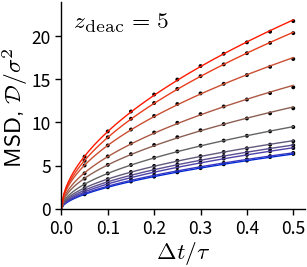

In [83]:
sm_phi = plt.cm.ScalarMappable(
    norm=plt.cm.colors.Normalize(vmin=0, vmax=1),
    cmap=colorcet.m_CET_D8,
)
valency = 5

fig, ax = plt.subplots(figsize=(1.6, 1.4))

for phi in np.arange(0, 1.01, 0.1):
    config_entry = (
        metrics_table
        .filter(pl.col("association_valency") == valency)
        .filter(pl.col("acetylation_level").is_between(phi - 0.01, phi + 0.01))
        .row(0, named=True)
    )
    config_id = config_entry["config_id"]
    alpha = config_entry["msd_exponent"]
    prefactor = config_entry["msd_prefactor"]

    msd = mean_msds[config_id]

    x = np.arange(1, len(msd)) * frame_duration
    y = msd[1:]
    ax.scatter(x, y, s=2, edgecolor="none", facecolor="k")

    x = np.linspace(0, 0.5, num=100)
    y = x**alpha * prefactor
    c = sm_phi.to_rgba(phi)
    ax.plot(x, y, color=c)

s = r"$ z_\mathrm{deac} = %d $" % valency
ax.text(0.05, 0.95, s, ha="left", va="top", usetex=True, transform=ax.transAxes)

ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax.set_xlim(0, )
ax.set_ylim(0, 24)

ax.set_xlabel(r"$ \Delta t / \tau $", usetex=True)
ax.set_ylabel("MSD, " + r"$ \mathcal{D} / \sigma^2 $", usetex=True)

set_axis(ax, "left bottom")

fig.savefig(f"_figs/msd-{task_id}-z{valency}.svg")

pass

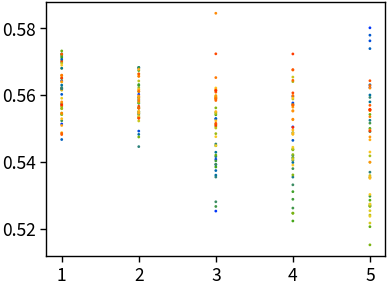

In [89]:
fig, ax = plt.subplots()

x = metrics_table["association_valency"]
y = metrics_table["msd_exponent"]
c = metrics_table["acetylation_level"]
ax.scatter(x, y, c=c, s=1, cmap=colorcet.m_rainbow)

pass

In [100]:
valency = 5
phi = 0
(
    metrics_table
    .filter(pl.col("association_valency") == valency)
    .filter(pl.col("acetylation_level").is_between(phi - 0.01, phi + 0.01))
    .row(0, named=True)
)

{'config_id': 204,
 'rg_mean': 2.8568949699401855,
 'rg_std': 0.06972359120845795,
 'msd_exponent': 0.5801322250306684,
 'msd_prefactor': 9.480498294644075,
 'association_valency': 5,
 'acetylation_level': 0.0}